In [1]:
import keras
from keras.datasets import boston_housing

from keras.models import Sequential
from keras.layers import Dense, Dropout

from sklearn import preprocessing
from sklearn.preprocessing import scale
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

x_train[0]

array([  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
        91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
        18.72   ])

In [3]:
x_test.shape

(102, 13)

In [4]:
x_train_scaled = preprocessing.scale(x_train)

x_train_scaled[0]

array([-0.27224633, -0.48361547, -0.43576161, -0.25683275, -0.1652266 ,
       -0.1764426 ,  0.81306188,  0.1166983 , -0.62624905, -0.59517003,
        1.14850044,  0.44807713,  0.8252202 ])

In [5]:

x_test_scaled = preprocessing.scale(x_test)
x_train_scaled[0]

array([-0.27224633, -0.48361547, -0.43576161, -0.25683275, -0.1652266 ,
       -0.1764426 ,  0.81306188,  0.1166983 , -0.62624905, -0.59517003,
        1.14850044,  0.44807713,  0.8252202 ])

In [6]:
model = Sequential()
model.add(Dense(256, activation='tanh', input_shape=(13,)))
model.add(Dropout(0.25))
model.add(Dense(64, activation='sigmoid'))
model.add(Dropout(0.25))
model.add(Dense(1, activation='relu'))

model.compile(loss='mse', optimizer='sgd', metrics=['mse'])


In [7]:
65*32

2080

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               3584      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 20,097
Trainable params: 20,097
Non-trainable params: 0
_________________________________________________________________


In [9]:
history = model.fit(x_train_scaled, y_train,
 batch_size=32,
epochs=500,
verbose=1,
validation_data = (x_test_scaled, y_test)
)

Epoch 1/500
13/13 [==============================] - 2s 27ms/step - loss: 112.1064 - mse: 112.1064 - val_loss: 23.6248 - val_mse: 23.6248
Epoch 2/500
13/13 [==============================] - 0s 6ms/step - loss: 34.1597 - mse: 34.1597 - val_loss: 22.4718 - val_mse: 22.4718
Epoch 3/500
13/13 [==============================] - 0s 6ms/step - loss: 28.2068 - mse: 28.2068 - val_loss: 25.3546 - val_mse: 25.3546
Epoch 4/500
13/13 [==============================] - 0s 9ms/step - loss: 27.2124 - mse: 27.2124 - val_loss: 24.4125 - val_mse: 24.4125
Epoch 5/500
13/13 [==============================] - 0s 12ms/step - loss: 27.9306 - mse: 27.9306 - val_loss: 22.9090 - val_mse: 22.9090
Epoch 6/500
13/13 [==============================] - 0s 7ms/step - loss: 26.6879 - mse: 26.6879 - val_loss: 22.9958 - val_mse: 22.9958
Epoch 7/500
13/13 [==============================] - 0s 10ms/step - loss: 25.6045 - mse: 25.6045 - val_loss: 25.2260 - val_mse: 25.2260
Epoch 8/500
13/13 [==============================]

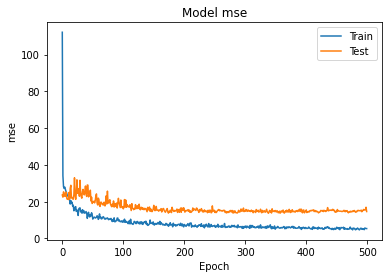

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('Model mse')
plt.ylabel('mse')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

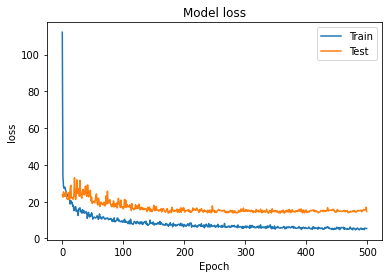

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

In [12]:
score = model.evaluate(x_test_scaled, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 14.642647743225098
Test accuracy: 14.642647743225098


In [13]:

prediction = model.predict(x_test_scaled)
print(prediction.flatten())
print(y_test)


[10.377742 18.64     21.254986 28.82167  23.44881  21.260986 30.381329
 21.78154  18.933842 20.349007 17.025389 16.224018 15.409079 43.318836
 12.209266 20.23087  25.024593 20.17305  18.579872 19.10144  10.474933
 12.344867 20.664244 17.33773  19.529394 20.67263  29.071548 28.218021
 10.542652 20.197659 20.220863 12.89678  32.273983 23.906338 15.547986
 10.345602 16.414804 19.227642 18.72128  27.062546 29.54815  27.073692
 11.686222 44.957947 33.3499   26.261745 27.577774 19.372982 20.748657
 23.230118 35.411163 20.767761 10.506623 13.496592 38.717278 27.328587
 10.843779 49.009617 33.371292 22.343687 22.301388 12.733342 12.404581
 19.716967 23.192505 20.797333 11.808947 22.36587  11.56211  10.336282
 19.050705 30.889156 20.272217 12.056264 26.371521 20.296978 19.864933
 24.785545 35.299274 10.435794 21.605549 38.66657  17.86522  11.961796
 19.10543  18.349823 12.776723 21.121773 21.843327 25.20228  19.127247
 18.974316 26.437847 35.95425  36.078026 21.311337 35.057644 42.3357
 24.3602

In [14]:
model.save('my_model.h5')